In [1]:
#| output: false
from Scripts import natama
from Scripts import goncalves

last_day, all_cause, malaria = natama.last_day_of_season()

T_r = all_cause['rabies']
T_m = all_cause['monthly']
T_d = all_cause['delayed']
D_r = malaria['rabies']
D_m = malaria['monthly']
D_d = malaria['delayed']

fold_change = natama.fold_change()
severe_risk, severe_risk_reduction = natama.severe_risk('../Data_Fitting/Goncalves/goncalves1_draws.csv')

p_goncalves = goncalves.get_estimates('../Data_Fitting/Goncalves/goncalves1_draws.csv')

# RH5.1 trial data

We were kindly given unpublished data from the phase 2b trial of the RH5.1/Matrix-M blood stage vaccine [@natama_safety_2024]. The vaccine was given to children aged 5–17 months in Nanoro, Burkina Faso. The trial had three arms: the control "rabies" arm with the rabies vaccine Rabivax-S, the "delayed" vaccine arm with regimen of RH5.1/Matrix-M at 0, 1, and 5 months and the "monthly" vaccine arm with regimen at 0, 1, and 2 months. Vaccinations were completed part way through the malaria season.

A mixture of passive and active case detection was employed. All presenting episodes of fever were recorded Both a blood spot was taken for parasite quantification and genotyping (this data, which will be analysed by qPCR, is not yet available) and a blood film for parasite detection by microscopy. Cumulative all-cause fevers for each arm are shown in [@fig-cumulative_episodes]A and cumulative fevers with detectable parasites by microscopy (>0 parasites/μl with fever in the last 24 h) are shown in [@fig-cumulative_episodes]B.

The plateau in the malaria fevers with detectable parasites is due to the malaria season coming to an end. Both of the vaccine arms show a clear reduction in fevers. The all-cause fevers are present throughout the malaria season and continue after the season has finished. There is a large reduction in all-cause fevers for the delayed arm, much larger than for the malaria fevers. As we discuss below, this suggests that there are a substantial number of malaria fevers without detectable parasites. These have not been recorded as malaria-associated fevers - because no parasites were detected by microscopy - but qPCR will hopefully quantify how many malaria fevers went undetected. 

We'll take the end of the malaria season as the last day a malaria fever occurred in the rabies are, this is day `{python} last_day` post last vaccination.

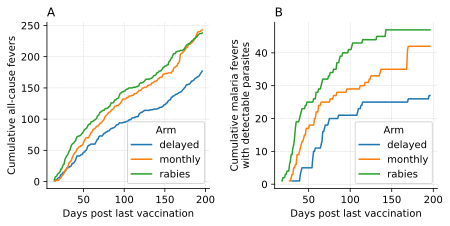

In [2]:
#| label: fig-cumulative_episodes
#| fig-cap: "A) Cumualtive all-cause fevers recorded either actively or passively for 200 days post last primary vaccination in the three trial arms of the phase 2b trial of the RH5.1/Matrix-M blood stage vaccine [@natama_safety_2024]. B) Cumulative clinical episodes (>0 parasites/μl by microscopy with fever in the last 24 h) in the three arms."

fig, axs = natama.clinical_time_series()

# Reduction of parasitaemia at presentation

The distributions of parasitaemias in clinical episodes with detectable parasites for each arm are shown in [@fig-parasitaemias]. There were `{python} D_r` episodes in the rabies arm, `{python} D_m` in the monthly arm (`{python} f"{(D_r-D_m)/D_r:.0%}"` reduction) and `{python} D_d` in the delayed arm (`{python} f"{(D_r-D_d)/D_r:.0%}"` reduction). The smallest parasitaemia recorded was `{python} f'{natama.rh5["Parasites per μl"].min():.0f}'` parasites/μl. This is shown as the vertical dashed line in [@fig-parasitaemias].

The monthly regimen caused a `{python} f"{fold_change['monthly']:.1f}"` fold-change in parasitaemia in clinical episodes with detectable parasites and the delayed regimen caused a `{python} f"{fold_change['delayed']:.1f}"` fold-change.

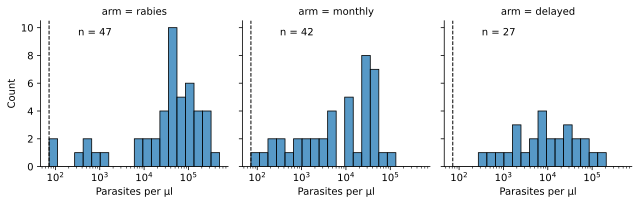

In [3]:
#| label: fig-parasitaemias
#| fig-cap: "Distributions of parasitaemia at presentation in each trial arm. The vertical dashed line in each panel is the smallest parasitaemia of 72 parasites/μl recorded across all episodes."

fig = natama.parasitaemia_distributions()

## Scenario 1: RH5.1 does not reduce risk of blood infection

Assuming that RH5.1 does not reduce the risk of infection, the results from @natama_safety_2024 imply that RH5.1 reduces the risk of blood infections becoming clinical. Although we focus our analysis on the delayed arm, as that reduced clinical malaria the most, we do estimate the effects of both vaccines arms. 

The delayed arm reduced the number of fever episodes with detectable parasites by `{python} D_r-D_d`. However, the number of all cause fever episodes dropped by `{python} T_r-T_d`. Making the reasonable assumption that non-malaria fevers occur at the same rate in all the trial arms, this implies that there were a number of malaria-associated fever episodes with **undetected** parasites in the rabies arm; of the order of at least `{python} (T_r-T_d)-(D_r-D_d)`, and probably more. Therefore, to quantify the reduction in risk of clinical malaria in the delayed arm, we must take into account malaria-associated fever episodes with undetected parasites. Unfortunately, the qPCR data that will indicate whether a fever episode was caused by malaria parasites or not is not yet available. So we currently do not have data that will quantify the number of fever episodes with undetected parasites. This means, in order to estimate the reduction in risk of clinical malaria in the delayed arm, we will to have to make some assumptions about how RH5.1 alters the risk of fever.

We know from @natama_safety_2024 that RH5.1 reduces parasitaemia in clinical episodes with detectable parasites. And we know from @goncalves_parasite_2014 that lower parasitaemias have lower risk of fever. Thus it seems reasonable that RH5.1 reduces the risk of fever by reducing parasitaemia. We also make the reasonable assumption that lower parasitaemias increase the chance that parasites become undetectable by microscopy. In [@fig-clinical_model] we set out a model of how RH5.1 may affect parasite detection and risk of fever by reducing parasitaemia. 

We assume that if a clinical episode in an unvaccinated child had detectable parasites, had that child been vaccinated the chance of detecting the parasites is lower by a proportion $\rho_\text{D}$. (For simplicity, we assume that if a clinical episode in an unvaccinated child had detectable parasites, had that child been vaccinated it would still have a clinical episode, i.e., it would not have had an asymptomatic infection.) In addition, we assume that if a clinical episode in an unvaccinated child had undetectable parasites, had that child been vaccinated the chance of it having a clinical episode is lower by a proportion $\rho_\text{U}$. Finally, vaccination does not reduce the chance of asymptomatic infection.   

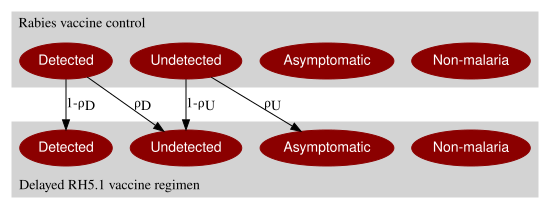

In [4]:
#| label: fig-clinical_model
#| fig-cap: "A possible model for how the delayed regimen of RH5.1 reduces the risk of clinical episodes by making asymptomatic infections more likely, and by making clinical episodes with detectable parasites less likely."

natama.clinical_model()

Let $D$ be the number of malaria-associated fever episodes with detected parasites, $U$ be the number of malaria-associated fever episodes with undetected parasite, $N$ be the number of non-malaria-associated fever episodes and let $T$ be the total number of fever episodes. We index these symbols with $r$ for the rabies arm and $d$ for the delayed arm.

For the rabies arm we have

$$
\begin{equation}
T_r = D_r + U_r + N_r \tag{1}
\end{equation}
$$ {#eq-eq1}

and for the delayed arm we have

$$
\begin{equation}
T_d = D_d + U_d + N_d \tag{2}
\end{equation}
$$ {#eq-eq2}

At the end of the season we know the all-cause fevers: $T_r=$ `{python} T_r`, $T_d=$ `{python} T_d`, and we know the malaria fevers with detectable parasites: $D_r=$ `{python} D_r` and $D_d=$ `{python} D_d`. We do not know the numbers of non-malaria fevers and the malaria fevers with undetectable parasites. 

Our above model makes the following relationships:

$$
\begin{equation}
D_d = [1-\rho_D] D_r \tag{3}
\end{equation}
$$ {#eq-eq3}
and
$$
\begin{align}
U_d &= [1-\rho_U] U_r + \rho_D D_r \\
 &= [1-\rho_U] U_r + D_r - D_d \tag{4}
\end{align}
$$ {#eq-eq4}

Immediately we see from [@eq-eq3] that

$$\rho_D = 1-\frac{D_d}{D_r} = 1-\frac{`{python} D_d`}{`{python} D_r`} = `{python} round(1-D_d/D_r, 2)`$$

In words, the delayed vaccine reduces the risk of a clinical episode having detectable parasites by `{python} f'{1-D_d/D_r:.0%}'`. To find $\rho_U$ we subtract [@eq-eq2] from [@eq-eq1] to obtain

$$
\begin{equation}
T_r-T_d = [D_r-D_d] + [U_r-U_d] + [N_r-N_d] \tag{5}
\end{equation}
$$ {#eq-eq5}

We have no reason to believe that the non-malaria fever rate is different between the trial arms. Therefore $N_r$ is likely to be similar to $N_d$. We assume, because we have no way to calculate these values, that $N_r=N_d$, simplifying [@eq-eq5] to,

$$
\begin{equation}
T_r-T_d = [D_r-D_d] + [U_r-U_d] \tag{6}
\end{equation}
$$ {#eq-eq6}

Substituting [@eq-eq4] into [@eq-eq6] we obtain

$$
\begin{align*}
T_r-T_d &= [D_r-D_d] + [U_r-[1-\rho_U] U_r - D_r + D_d] \\
`{python} T_r` -`{python} T_d` &= \rho_U U_r\\
`{python} T_r-T_d` &= \rho_U U_r
\end{align*}
$$


The problem that now arises is that we have no data to parameterise $\rho_U$ and $U_r$. However, we can put bounds on $U_r$. First, $U_r$ must be greater than `{python} T_r-T_d` episodes because $\rho_U$ lies between zero and one. Second, hypothetically, if there were no non-malaria fevers (i.e., $N_r=0$) then from [@eq-eq1], $\max(U_r)=T_r-D_r=$ `{python} T_r` - `{python} D_r` = `{python} T_r-D_r`. So the maximum value of $U_r$ is `{python} T_r-D_r` episodes. However, it is clear in the data that there is a substantial fraction of non-malaria fevers as total fevers continues to rise past the end of the malaria season. So $U_r$ will be substantially lower than this theoretical maximum.

(We were hoping to use the non-malaria fever episode rate after the end of the season - about `{python} last_day` days post vaccination - to subtract non-malaria fevers from the total fevers during the season. The non-malaria fever episode rate after the end of season is about 1 episode per arm per day ([@fig-cumulative_episodes]). If this rate occurred during the season we would expect to see more than about `{python} last_day` fever episodes in total by `{python} last_day` days in each arm. In fact, we see only about 120 episodes in the delayed arm. This suggests that the non-malaria fever episode rate is, on average, lower during the season than after it. Hence, we cannot use the rate at the end of season to estimate the number of non-malaria episodes during the season.)

Let $\omega_\text{clinical}$ be the proportional reduction in the risk of clinical malaria of RH5.1. Its value is one minus the ratio of clinical episodes between the delayed and rabies arms:

$$
\begin{equation}
\omega_\text{clinical} = 1 - \frac{U_d+D_d}{U_r+D_r} \tag{7}
\end{equation}
$$ {#eq-eq7}

Rearranging [@eq-eq6] we get $U_d+D_d = U_r+D_r - [T_r-T_d]$. Substituting into [@eq-eq7] we get 

$$
\begin{align*}
\omega_\text{clinical} &= 1 - \frac{U_r+D_r - [T_r-T_d]}{U_r+D_r}\\
\omega_\text{clinical} &= \frac{T_r-T_d}{U_r+D_r}\\
 &= \frac{`{python} T_r-T_d`}{U_r+`{python} D_r`}\\
\end{align*}
$$

The relationship between $\omega_\text{clinical}$ and $U_r$ is shown in [@fig-omega_clinical] for $Ur=(59, 130)$. $\omega_\text{clinical}$ is relatively insensitive to changes in $U_r$, varying between 0.35 and 0.55. We expect $U_r$ to be at the lower end of the range because of the substantial number of non-malaria fevers. As a default value for our full model we will assume $\omega_\text{clinical}=0.5$.

For the monthly vaccine arm we find that $\omega_\text{clinical} \approx 0.1$ ([@fig-omega_clinical]).


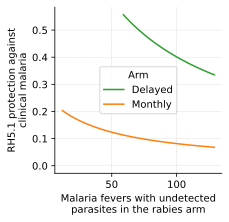

In [5]:
#| label: fig-omega_clinical
#| fig-cap: "Predicted relationship between RH5.1's proportional reduction in risk of clinical malaria ($\\omega_\\text{clinical}$) against the number of malaria fevers with undetected parasites in the rabies arm at the end of the malaria season ($U_r$). The lower and upper bounds on $U_r$ are 59 and 130, although the substantial number of non-malaria fevers will greatly reduce this upper bound."

fig, ax = natama.omega_clinical(T_r-T_d, T_r-T_m, D_r)

## Scenario 2: RH5.1 reduces the risk of blood infections

In this scenario RH5.1 reduces the risk of blood infection. 

We assume that if an infection occurs in an unvaccinated child, had that child been vaccinated the chance of an infection is lower by an amount $\rho$. This applies equally to fevers with and without detectable parasites and asymptomatic infections ([@fig-blood_model]).


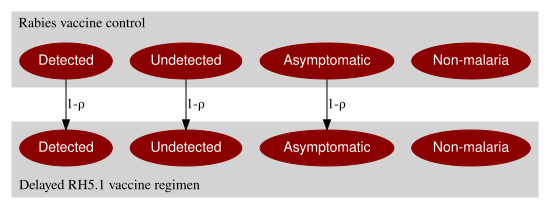

In [6]:
#| label: fig-blood_model
#| fig-cap: "A possible model for how the delayed regimen of RH5.1 reduces clinical episodes by reducing the risk of infection. Clinical episodes, with and without detectable parasites, and asymptomatic infections are all reduced by a proportion $\\rho$."

natama.blood_model()

Again, we see that

$$\rho = 1-\frac{D_d}{D_r} = 1-\frac{`{python} D_d`}{`{python} D_r`} = `{python} round(1-D_d/D_r, 2)`$$

We can find $U_r$ as follows. Substitute $U_d=[1-\rho] U_r$ into [@eq-eq6] to obtain

$$T_r-T_d = D_r-D_d + \rho U_r$$

Re-arranging and substituting the known values in we obtain

$$U_r = \frac{`{python} (T_r-T_d-D_r+D_d)`}{\rho}$$

Substituting in $\rho=$ `{python} round(1-D_d/D_r, 2)` gives $U_r =$  `{python} int(round((T_r-T_d-D_r+D_d)/(1-D_d/D_r), 0))` episodes and $U_d=`{python} (T_r-T_d-D_r+D_d)`\frac{1-\rho}{\rho}=$ `{python} int(round((T_r-T_d-D_r+D_d)*(D_d/D_r)/(1-D_d/D_r), 0))` episodes.

In words, if RH5.1 solely reduces the risk of blood infection, we expect about `{python} int(round((T_r-T_d-D_r+D_d)/(1-D_d/D_r), 0))` clinical episodes with undetected parasites in the rabies arm and about `{python} int(round((T_r-T_d-D_r+D_d)*(D_d/D_r)/(1-D_d/D_r), 0))` in the delayed arm. 

Let $\omega_\text{infection}$ be the proportional reduction in the risk of blood infection of RH5.1. Its value is one minus the ratio of infections between the delayed and rabies arms:

$$\omega_\text{infection} = 1 - \frac{U_d+D_d+A_d}{U_r+D_r+A_r}$$

where $A_d$ and $A_r$ are the number of asymptomatic infections in the delayed and rabies arms respectively. Using the model in @fig-blood_model we have

$$
\begin{align*}
\omega_\text{infection} &= 1 - \frac{[1-\rho] U_r+[1-\rho] D_r+[1-\rho] A_r}{U_r+D_r+A_r} \\
\omega_\text{infection} &= 1 - [1-\rho]\frac{ U_r+ D_r+ A_r}{U_r+D_r+A_r} \\
&= \rho \\
&= `{python} round(1-D_d/D_r, 2)`
\end{align*}
$$

Therefore, if RH5.1 solely reduces the risk of blood infection it reduces it by about `{python} f"{1-D_d/D_r:.0%}"`.

For the monthly arm we find that $\omega_\text{infection} =$ `{python} round(1-D_m/D_r, 2)`.

How do we determine the actual values of $\omega_\text{infection}$ and $\omega_\text{clinical}$? By measuring the ratios between control and vaccine arms of clinical malaria episodes with detected parasites, clinical malaria episodes with undetected parasites and asymptomatic episodes. The latter is particularly important for determining if RH5.1 reduces the risk of infection (ratio < 1) or not (ratio > 1). 

# RH5.1 reduction in risk of severe malaria due to reduced average parasitaemia at presentation

The fold-reduction in parasitaemia is estimated to be `{python} f"{fold_change['delayed']:.1f}"` in the delayed arm and `{python} f"{fold_change['monthly']:.1f}"` in the monthly arm ([@fig-parasitaemias]). These reductions only applies to the clinical episodes that had detectable parasites. The fold-reduction in parasitaemia in episodes without detectable parasites, and the total fold-reduction in parasitaemia in of all clinical episodes, are unknown at this time. qPCR data, when it becomes available, may be able to shed light on this.

Although the trial was not designed to assess whether RH5.1 reduces the risk of severe malaria, we can predict this reduction using the changes in the observed parasitaemias. From @goncalves_parasite_2014 we estimated that the probability of clinical malaria becoming severe on first infection given a log-parasitaemia at presentation of $x$, is

$$\text{Pr}(\text{severe}|\text{fever},x) = \frac{`{python} round(p_goncalves.bS.mean(), 2)`}{1+\exp(-`{python} round(p_goncalves.aS.mean(), 1)`[x-`{python} round(p_goncalves.cS.mean(), 1)`])}$$

For each arm we substitute the parasitaemias into this equation and take the average of the resulting probabilities. We find that the risk of severe malaria on first infection is `{python} f"{severe_risk['rabies'].mean():.1%}"` $\pm$ `{python} f"{severe_risk['rabies'].std():.1%}"` in the rabies arm, `{python} f"{severe_risk['delayed'].mean():.1%}"` $\pm$ `{python} f"{severe_risk['delayed'].std():.1%}"` in the delayed arm and `{python} f"{severe_risk['monthly'].mean():.1%}"` $\pm$ `{python} f"{severe_risk['monthly'].std():.1%}"` in the monthly arm. 

Therefore, RH5.1 potentially reduces the risk of severe malaria on first infection by about `{python} f"{severe_risk_reduction['monthly'].mean():.0%}"` $\pm$ `{python} f"{severe_risk_reduction['monthly'].std():.0%}"` in the monthly arm and `{python} f"{severe_risk_reduction['delayed'].mean():.0%}"` $\pm$ `{python} f"{severe_risk_reduction['delayed'].std():.0%}"` in the delayed arm. 

This result will certainly depend on the parasitaemias in the episodes with undetected parasites, but without further data, this is our best initial estimate.

# Waning immunity

Our estimates for the reduction in the risks of blood infection, clinical malaria and severe malaria ($\omega_\text{infection}$, $\omega_\text{clinical}$ and $\omega_\text{severe}$) are averages over the first malaria season of the @natama_safety_2024 RH5.1 trial. But the efficacy of RH5.1 wanes rapidly within half a year [@silk_blood-stage_2024]. This waning efficacy needs to be taken into account in the epidemiological model.

We use the anti-RH5.1 IgG antibody profiles from @silk_blood-stage_2024 as proxies for the protection profiles of RH5.1, as was done for RTS,S [@white_vaccine_2015] and R21 [@schmit_public_2024]. The profiles of the delayed and monthly arms are reproduced from Figure S4 of @silk_blood-stage_2024 in @fig-rh5_antibody_profiles.

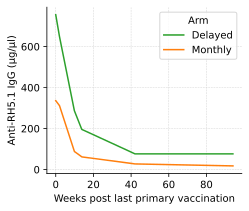

In [7]:
#| label: fig-rh5_antibody_profiles
#| fig-cap: "Median anti-RH5.1 IgG antibody profiles as measured by ELISA of the delayed and monthly arms reproduced from Figure S4 of @silk_blood-stage_2024. The profiles are from the 10D group of children two weeks after the last primary dose."

fig, ax = natama.rh5_antibody_profiles()

## Waning immunity to clinical malaria

To scale the anti-RH5.1 IgG antibody profiles appropriately we need the total (detected plus undetected) clinical episode rate in the rabies arm, termed $c_r(t)$. We can obtain the clinical episode rates with detectable parasites by first fitting a linear GAM to each arm ([@fig-episode_rates]A), and then calculating their derivatives ([@fig-episode_rates]B). Code is available in [Scripts/natama.py](Scripts/natama.py).

The vaccine clearly reduces the rate of clinical episodes with detectable parasites, and more so in the delayed arm than in the monthly arm. The control arm has a first peak at one episode per week at 2 weeks. The first peaks in the two vaccine arms occur a few weeks later and at lower rates probably due to the vaccine reducing parasite growth rate - i.e., it takes longer for the parasite populations to reach a pyrogenic threshold.

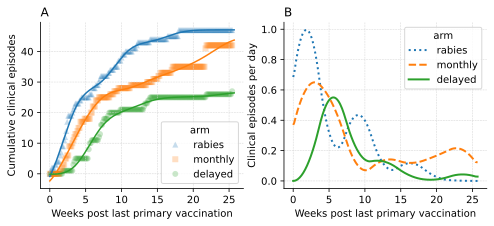

In [8]:
#| label: fig-episode_rates
#| fig-cap: Cumulative clinical episodes (>0 parasites/μl by microscopy with fever in the last 24 h) in the three arms. Symbols - data, lines - linear GAM fits (monotonic increasing constraint and ten splines). B) The estimated clinical episode rates are the derivatives of the linear GAM fits.

fig, axs, days, pdep = natama.clinical_rates()

In [9]:
#| output: false
alpha_clinical_delayed, alpha_severe_delayed, alpha_clinical_monthly, alpha_severe_monthly = natama.find_alpha_waning_immunity(days, pdep)
print(alpha_clinical_delayed, alpha_severe_delayed)
print(alpha_clinical_monthly, alpha_severe_monthly)

0.0019695415377859802 0.0013239411185131187
0.004504155349145742 0.002975115538611942


Let $c_d(t)$ be the clinical episode rate for the delayed arm (green line in [@fig-episode_rates]B). Let $q(t)$ be the vaccine-induced, time-dependent relative reduction in clinical episodes. Therefore

$$
c_d(t) = [1-q(t)]c_r(t) \tag{8}
$$ {#eq-eq8}

We assume that the relative reduction in clinical episodes, $q(t)$, is proportional to the antibody profile $p(t)$ ([@fig-rh5_antibody_profiles]) with proportionality constant $\alpha$, i.e., $q(t) = \alpha p(t)$. Substituting this into [@eq-eq8] and integrating both sides we get 

$$
\begin{align*}
\int_0^\infty c_d(t)\,dt &= \int_0^\infty [1-\alpha p(t)]c_r(t)\,dt \\
&= \int_0^\infty c_r(t)\,dt -\alpha \int_0^\infty p(t)c_r(t)\,dt \\
\end{align*}
$$

Let $F_d=U_d+D_d$ be the number of malaria clinical episodes in the delayed arm, and let $F_r=U_r+D_r$ be that in the rabies arm. Therefore

$$F_d = F_r - \alpha \int_0^\infty p(t)c_r(t)\,dt$$

Rearranging gives

$$
\alpha = \frac{F_r-F_d}{\int_0^\infty p(t)c_r(t)\,dt} \tag{9}
$$ {#eq-eq9}

Now $F_d=[1-\omega_\text{clinical}]F_r$ where $\omega_\text{clinical}$ is the reduction in risk of clinical malaria. Substituting into [@eq-eq9] gives

$$\alpha = \omega_\text{clinical}\frac{F_r}{\int_0^\infty p(t)c_r(t)\,dt}$$

Let $\alpha_\text{clinical} = \frac{F_r}{\int_0^\infty p(t)c_r(t)\,dt}$ giving $\alpha=\omega_\text{clinical} \alpha_\text{clinical}$. Therefore, the time-dependent reduction in risk of infection of clinical malaria is given by

$$q(t) = \omega_\text{clinical} \alpha_\text{clinical} p(t)$$

To obtain $\alpha_\text{clinical}$ we need to decompose $F_r$ and $c_r(t)$ into clinical episodes with detected and undetected parasites:

$$\alpha_\text{clinical} = \frac{U_r+D_r}{\int_0^\infty p(t)[c_{r,U}(t)+c_{r,D}(t)]\,dt}$$

But because the ratio of the two numerator terms equals the ratio of the two denominator terms we can drop the clinical episodes with undetected parasites and work with just the clinical episodes with detected parasites:

$$\alpha_\text{clinical} = \frac{D_r}{\int_0^\infty p(t)c_{r,D}(t)\,dt}$$

At the end of the season $D_r=$ `{python} D_r`. The integral can be solved numerically ([Scripts/natama.py](Scripts/natama.py)) to obtain $\alpha_\text{clinical} = `{python} round(alpha_clinical_delayed, 3)`$ for the delayed arm and `{python} round(alpha_clinical_monthly, 3)` for the monthly arm.

## Waning immunity to infection

The same argument applies to waning immunity in infection. The only difference is that $F_d$ and $F_r$ are the total number of infections (clinical plus asymptomatic), $F_d=[1-\omega_\text{infection}]F_r$ and $q(t) = \omega_\text{infection} \alpha_\text{infection} p(t)$. However, as for clinical malaria, factors cancel and we obtain identical results: $\alpha_\text{infection} = `{python} round(alpha_clinical_delayed, 3)`$ for the delayed arm and `{python} round(alpha_clinical_monthly, 3)` for the monthly arm.


## Waning immunity to severe malaria

As there are no severe malaria data in @natama_safety_2024 and @silk_blood-stage_2024 we do not know how many severe malaria episodes vaccination averted. Therefore we cannot find a scaling parameter to convert antibody levels to protection. Instead we scale the antibody titres so that their maximum is 1. That is:

$$\alpha_\text{severe} = \frac{1}{\max(p(t))} = `{python} round(alpha_severe_delayed, 4)`$$

for the delayed arm, and 

$$\alpha_\text{severe} = \frac{1}{\max(p(t))} = `{python} round(alpha_severe_monthly, 4)`$$

for the monthly arm.

::: {#refs}
:::